# KCGS ESG 평가등급 EDA (개선판, 실제 데이터로 실행)

원본 노트북의 실행 순서 오류, 누락 코드, 반복 코드를 정리하고 아래 인사이트 분석을 추가해
업로드하신 실제 데이터(`KCGS_평가등급_2022-2025_최호연_수정.csv`, 377행, 118개 기업)로 실행한 결과입니다.

## 1. 데이터 로드

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

pd.set_option('display.max_columns', None)
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

file_path = r'C:\Users\wpqlc\OneDrive\바탕 화면\ESG 데이터\KCGS_평가등급_2022-2025_최호연 수정.csv'
df = pd.read_csv(file_path)
display(df.head())


,기업명,기업코드,평가년도,ESG등급,환경,사회,지배구조,ESG 등급조정,환경 등급조정,사회 등급조정,지배구조 등급조정,시장구분,업종명,종가,대비,등락률,시가총액,지속가능경영보고서_발행,기업지배구조보고서_발행,보고서_발행_유형
0,에스앤에스텍,101490,2022,C,D,D,B,NaN,NaN,NaN,NaN,KOSDAQ,전기·전자,NaN,NaN,NaN,NaN,0,0,미발행
1,에스앤에스텍,101490,2023,C,D,D,B+,NaN,NaN,NaN,NaN,KOSDAQ,전기·전자,NaN,NaN,NaN,NaN,0,0,미발행
2,에스앤에스텍,101490,2024,C,D,D,B+,NaN,NaN,NaN,NaN,KOSDAQ,전기·전자,NaN,NaN,NaN,NaN,0,0,미발행
3,에스앤에스텍,101490,2025,C,D,D,B+,NaN,NaN,NaN,NaN,KOSDAQ,전기·전자,48300.0,50.0,0.1,1.030470e+12,0,0,미발행
4,일진전기,103590,2022,D,D,C,D,NaN,NaN,NaN,NaN,KOSPI,전기·전자,NaN,NaN,NaN,NaN,0,0,미발행


## 2. 기본 정보 및 결측치 확인

In [86]:
print(df.info())
print(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   기업명           377 non-null    str    
 1   기업코드          377 non-null    int64  
 2   평가년도          377 non-null    int64  
 3   ESG등급         377 non-null    str    
 4   환경            377 non-null    str    
 5   사회            377 non-null    str    
 6   지배구조          377 non-null    str    
 7   ESG 등급조정      0 non-null      float64
 8   환경 등급조정       0 non-null      float64
 9   사회 등급조정       0 non-null      float64
 10  지배구조 등급조정     1 non-null      str    
 11  시장구분          377 non-null    str    
 12  업종명           377 non-null    str    
 13  종가            101 non-null    float64
 14  대비            101 non-null    float64
 15  등락률           101 non-null    float64
 16  시가총액          101 non-null    float64
 17  지속가능경영보고서_발행  377 non-null    int64  
 18  기업지배구조보고서_발행  377 non-null    int64  
 19

In [87]:
print(df['평가년도'].value_counts().sort_index())


평가년도
2022     92
2023     88
2024     96
2025    101
Name: count, dtype: int64


In [88]:
missing_values = df.isnull().sum()
print("각 컬럼별 결측치 개수:")
display(missing_values[missing_values > 0].sort_values(ascending=False))


각 컬럼별 결측치 개수:


ESG 등급조정     377
환경 등급조정      377
사회 등급조정      377
지배구조 등급조정    376
종가           276
대비           276
등락률          276
시가총액         276
dtype: int64

## 3. 재사용 함수 정의

"연도별 등급 카운트 → 재정렬 → 누적막대"와 "상위/하위 5개 기업" 로직을 함수화했습니다.

In [89]:
GRADE_ORDER = ['S', 'A+', 'A', 'B+', 'B', 'C', 'D']
GRADE_TO_SCORE = {'S': 7, 'A+': 6, 'A': 5, 'B+': 4, 'B': 3, 'C': 2, 'D': 1}

def get_grade_counts(data, col, order=GRADE_ORDER):
    counts = data.groupby(['평가년도', col]).size().unstack(fill_value=0)
    cols = [g for g in order if g in counts.columns]
    return counts[cols]

def plot_grade_heatmap(counts, title, ax=None):
    sns.heatmap(counts, annot=True, fmt='d', cmap='YlGnBu', cbar=False,
                ax=ax, linewidths=0.5, linecolor='white')
    target = ax if ax is not None else plt.gca()
    target.set_title(title)
    target.set_xlabel('등급')
    target.set_ylabel('평가년도')

def top_bottom_by_score(data_scored, score_col, group_col='기업명', n=5):
    total = data_scored.groupby(group_col)[score_col].sum().reset_index()
    total.rename(columns={score_col: f'전체_{score_col}'}, inplace=True)
    top = total.sort_values(f'전체_{score_col}', ascending=False).head(n)
    bottom = total.sort_values(f'전체_{score_col}', ascending=True).head(n)
    return top, bottom

df_scored = df.copy()
df_scored['ESG_점수'] = df_scored['ESG등급'].map(GRADE_TO_SCORE)
df_scored['환경_점수'] = df_scored['환경'].map(GRADE_TO_SCORE)
df_scored['사회_점수'] = df_scored['사회'].map(GRADE_TO_SCORE)
df_scored['지배구조_점수'] = df_scored['지배구조'].map(GRADE_TO_SCORE)
df_scored['총점수'] = (df_scored['ESG_점수'] + df_scored['환경_점수']
                     + df_scored['사회_점수'] + df_scored['지배구조_점수'])


## 4. 연도별 ESG / 환경 / 사회 / 지배구조 등급 분포

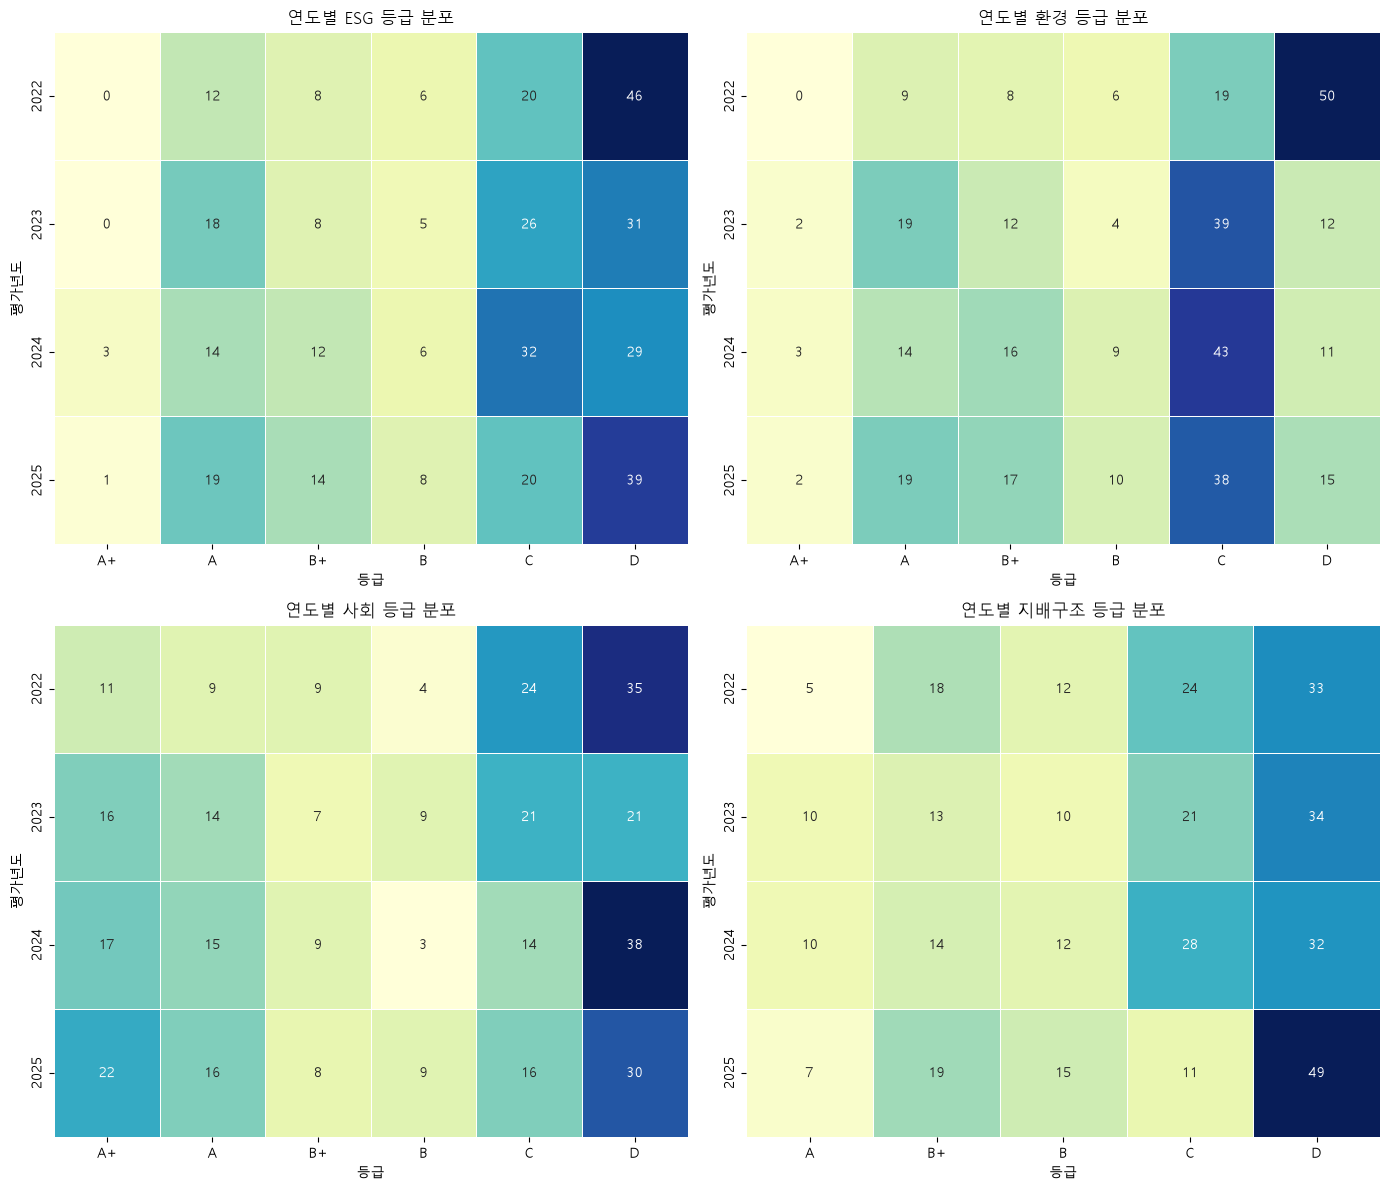

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plot_grade_heatmap(get_grade_counts(df, 'ESG등급'), '연도별 ESG 등급 분포', axes[0, 0])
plot_grade_heatmap(get_grade_counts(df, '환경'), '연도별 환경 등급 분포', axes[0, 1])
plot_grade_heatmap(get_grade_counts(df, '사회'), '연도별 사회 등급 분포', axes[1, 0])
plot_grade_heatmap(get_grade_counts(df, '지배구조'), '연도별 지배구조 등급 분포', axes[1, 1])
plt.tight_layout()
plt.show()


## 5. E · S · G 점수 간 상관관계

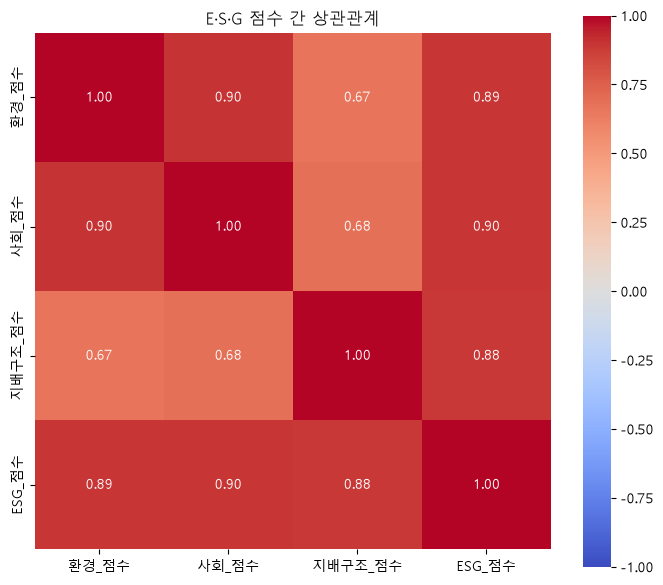

,환경_점수,사회_점수,지배구조_점수,ESG_점수
환경_점수,1.000000,0.900984,0.670055,0.894345
사회_점수,0.900984,1.000000,0.684576,0.896087
지배구조_점수,0.670055,0.684576,1.000000,0.884221
ESG_점수,0.894345,0.896087,0.884221,1.000000


In [91]:
corr_cols = ['환경_점수', '사회_점수', '지배구조_점수', 'ESG_점수']
corr = df_scored[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('E·S·G 점수 간 상관관계')
plt.tight_layout()
plt.show()
display(corr)


## 6. 기업별 ESG 등급 변화 추적 (2022 → 2025)

In [92]:
pivot_esg = df_scored.pivot_table(index='기업명', columns='평가년도', values='ESG_점수')
years_available = sorted(df_scored['평가년도'].unique())
first_year, last_year = years_available[0], years_available[-1]

change_df = pivot_esg.dropna(subset=[first_year, last_year]).copy()
change_df['변화량'] = change_df[last_year] - change_df[first_year]

n_improved = (change_df['변화량'] > 0).sum()
n_declined = (change_df['변화량'] < 0).sum()
n_same = (change_df['변화량'] == 0).sum()

print(f"{first_year}년 -> {last_year}년 비교 (양쪽 다 데이터 있는 기업 {len(change_df)}개)")
print(f" - 개선: {n_improved}개 / 하락: {n_declined}개 / 동일: {n_same}개")

print("\n--- 가장 크게 개선된 기업 top 10 ---")
display(change_df.sort_values('변화량', ascending=False).head(10)[[first_year, last_year, '변화량']])

print("\n--- 가장 크게 하락한 기업 top 10 ---")
display(change_df.sort_values('변화량').head(10)[[first_year, last_year, '변화량']])


2022년 -> 2025년 비교 (양쪽 다 데이터 있는 기업 77개)
 - 개선: 30개 / 하락: 8개 / 동일: 39개

--- 가장 크게 개선된 기업 top 10 ---


평가년도,2022,2025,변화량
기업명,,,
대주전자재료,1.0,4.0,3.0
심텍,2.0,5.0,3.0
솔루스첨단소재,2.0,4.0,2.0
드림텍,1.0,3.0,2.0
경동나비엔,2.0,4.0,2.0
이녹스첨단소재,2.0,4.0,2.0
엘앤에프,2.0,4.0,2.0
하나머티리얼즈,1.0,3.0,2.0
한국단자공업,1.0,3.0,2.0



--- 가장 크게 하락한 기업 top 10 ---


평가년도,2022,2025,변화량
기업명,,,
효성중공업,5.0,3.0,-2.0
KEC,2.0,1.0,-1.0
리노공업,2.0,1.0,-1.0
RFHIC,2.0,1.0,-1.0
삼영전자공업,2.0,1.0,-1.0
서울반도체,3.0,2.0,-1.0
신도리코,2.0,1.0,-1.0
대동전자,2.0,1.0,-1.0
광명전기,1.0,1.0,0.0


,기업 수
점수 변화량,
-2.0,1
-1.0,7
0.0,39
1.0,21
2.0,7
3.0,2


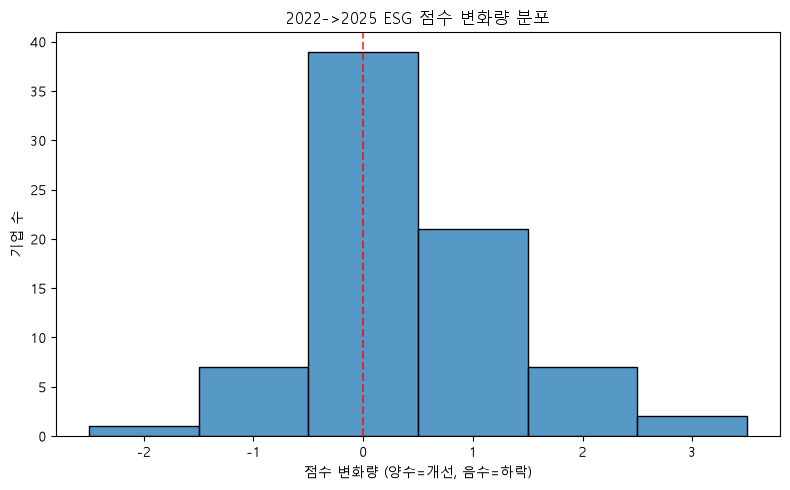

In [93]:
change_dist = (change_df['변화량']
               .value_counts()
               .sort_index()
               .rename('기업 수')
               .to_frame())
change_dist.index.name = '점수 변화량'
display(change_dist)

plt.figure(figsize=(8, 5))
sns.histplot(change_df['변화량'], bins=range(int(change_df['변화량'].min())-1, int(change_df['변화량'].max())+2), discrete=True)
plt.title(f'{first_year}->{last_year} ESG 점수 변화량 분포')
plt.xlabel('점수 변화량 (양수=개선, 음수=하락)')
plt.ylabel('기업 수')
plt.axvline(0, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 7. 시가총액과 ESG 등급의 관계 (최신 연도 기준)

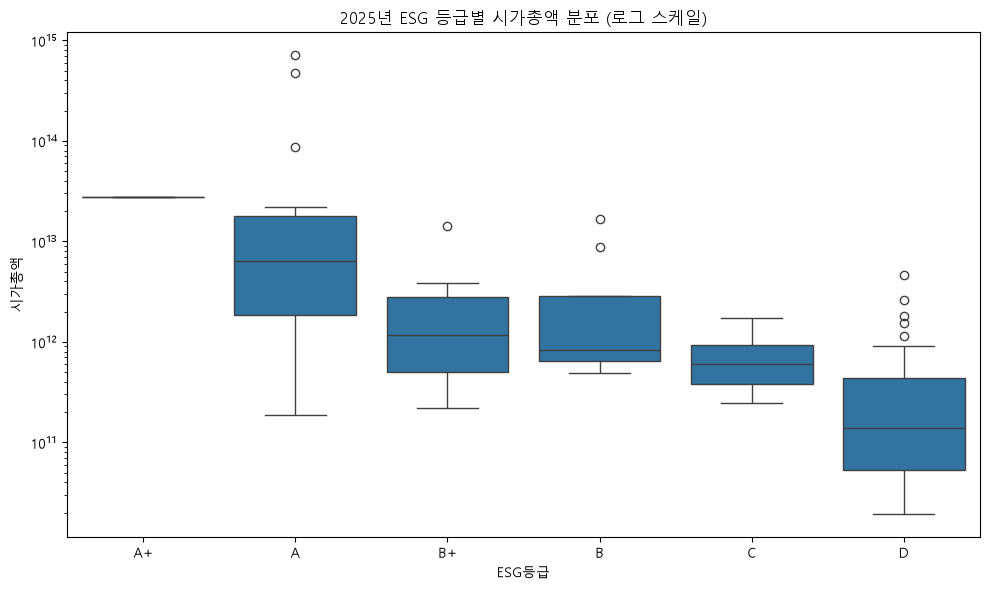

ESG 점수와 시가총액(로그) 간 스피어만 상관계수: 0.707


In [94]:
df_latest = df_scored[df_scored['평가년도'] == last_year].dropna(subset=['시가총액']).copy()
order = [g for g in GRADE_ORDER if g in df_latest['ESG등급'].unique()]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_latest, x='ESG등급', y='시가총액', order=order)
plt.yscale('log')
plt.title(f'{last_year}년 ESG 등급별 시가총액 분포 (로그 스케일)')
plt.tight_layout()
plt.show()

log_cap = np.log10(df_latest['시가총액'].clip(lower=1))
spearman_corr = df_latest['ESG_점수'].corr(log_cap, method='spearman')
print(f"ESG 점수와 시가총액(로그) 간 스피어만 상관계수: {spearman_corr:.3f}")


## 8. 보고서 발행 여부와 ESG 점수의 관계

,mean,count
보고서_발행_유형,,
둘 다 발행,4.454545,22
지속가능경영만,4.000000,2
지배구조만,2.888889,18
미발행,2.283582,335


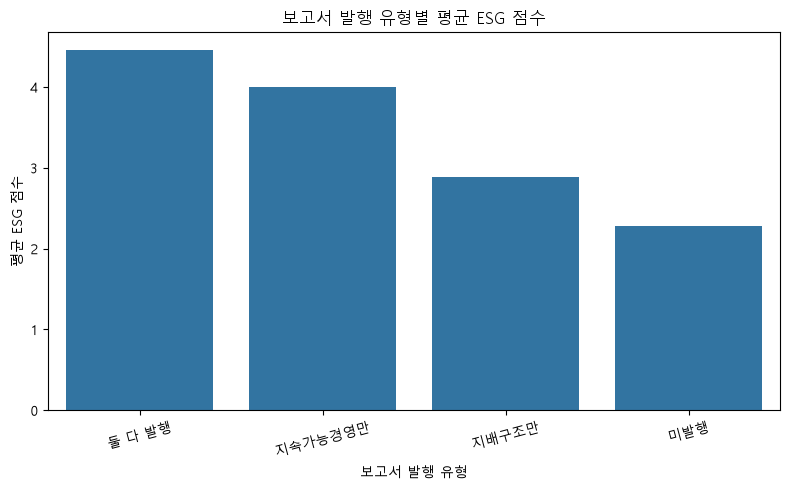

In [95]:
report_compare = df_scored.groupby('보고서_발행_유형')['ESG_점수'].agg(['mean', 'count']).sort_values('mean', ascending=False)
display(report_compare)

plt.figure(figsize=(8, 5))
sns.barplot(x=report_compare.index, y=report_compare['mean'])
plt.title('보고서 발행 유형별 평균 ESG 점수')
plt.xlabel('보고서 발행 유형')
plt.ylabel('평균 ESG 점수')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 9. 시장구분(KOSPI/KOSDAQ)별 ESG 점수 비교

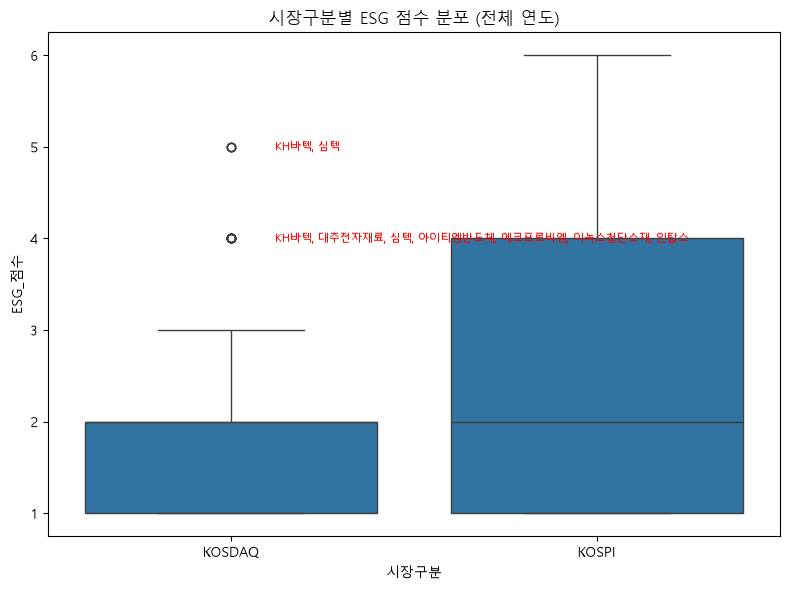

,mean,median,count
시장구분,,,
KOSDAQ,2.000000,2.0,122
KOSPI,2.662745,2.0,255


In [97]:
market_order = ['KOSDAQ', 'KOSPI']

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_scored, x='시장구분', y='ESG_점수', order=market_order)
plt.title('시장구분별 ESG 점수 분포 (전체 연도)')

kosdaq_scores = df_scored.loc[df_scored['시장구분'] == 'KOSDAQ', 'ESG_점수']
q1, q3 = kosdaq_scores.quantile(0.25), kosdaq_scores.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

kosdaq_outliers = df_scored[(df_scored['시장구분'] == 'KOSDAQ') &
                             ((df_scored['ESG_점수'] < lower) | (df_scored['ESG_점수'] > upper))]

kosdaq_x = market_order.index('KOSDAQ')
for score, grp in kosdaq_outliers.groupby('ESG_점수'):
    companies = ', '.join(sorted(grp['기업명'].unique()))
    plt.text(kosdaq_x + 0.12, score, companies, color='red', fontsize=8, ha='left', va='center')

plt.tight_layout()
plt.show()
display(df_scored.groupby('시장구분')['ESG_점수'].agg(['mean', 'median', 'count']))


## 10. 부문별 상위/하위 5개 기업 (전체 기간 합산)

In [98]:
score_labels = [('총점수', '종합'), ('환경_점수', '환경'), ('사회_점수', '사회'), ('지배구조_점수', '지배구조')]

top_result = pd.DataFrame(index=range(1, 6))
bottom_result = pd.DataFrame(index=range(1, 6))

for score_col, label in score_labels:
    top, bottom = top_bottom_by_score(df_scored, score_col)
    score_field = f'전체_{score_col}'
    top_result[label] = [f"{row['기업명']} ({row[score_field]:.0f})" for _, row in top.reset_index(drop=True).iterrows()]
    bottom_result[label] = [f"{row['기업명']} ({row[score_field]:.0f})" for _, row in bottom.reset_index(drop=True).iterrows()]

top_result.index.name = '순위'
bottom_result.index.name = '순위'

print("=== 부문별 상위 5개 기업 ===")
display(top_result)
print("=== 부문별 하위 5개 기업 ===")
display(bottom_result)


=== 부문별 상위 5개 기업 ===


,종합,환경,사회,지배구조
순위,,,,
1,LG이노텍 (84),삼성SDI (22),LG이노텍 (24),LG이노텍 (20)
2,삼성SDI (84),LG전자 (21),두산퓨얼셀 (24),엘에스일렉트릭 (20)
3,삼성전기 (83),삼성전기 (20),삼성전기 (24),한화시스템 (19)
4,LG전자 (82),LG이노텍 (20),삼성SDI (24),삼성전기 (19)
5,한화시스템 (82),효성중공업 (20),한화시스템 (24),LG전자 (18)


=== 부문별 하위 5개 기업 ===


,종합,환경,사회,지배구조
순위,,,,
1,비덴트 (4),대아티아이 (1),대아티아이 (1),비덴트 (1)
2,하이트론씨스템즈 (4),가온칩스 (1),가온칩스 (1),일진머티리얼즈 (1)
3,일진머티리얼즈 (4),서울바이오시스 (1),비덴트 (1),엘비세미콘 (1)
4,엠투엔 (4),비덴트 (1),디티알오토모티브 (1),하이트론씨스템즈 (1)
5,제주반도체 (5),오이솔루션 (1),제주반도체 (1),제주반도체 (1)


## 11. 시가총액 이상치 확인 (최신 연도)

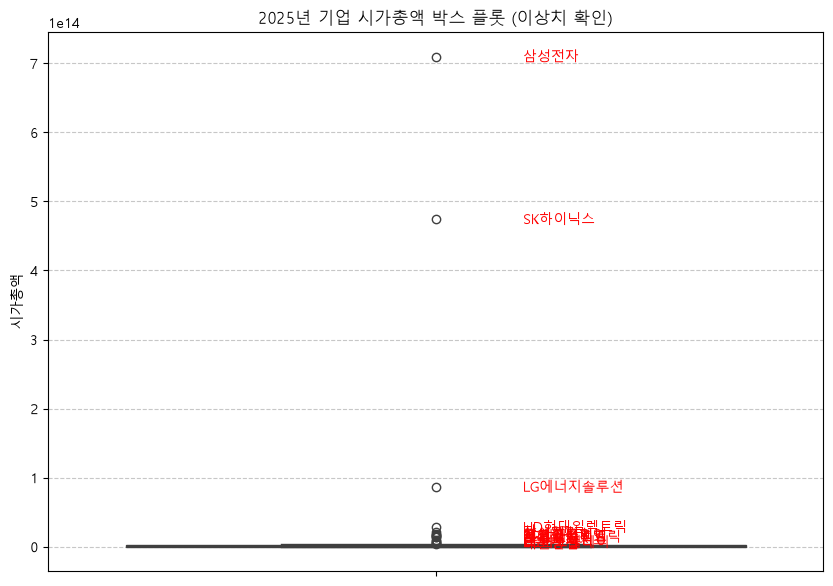

In [99]:
plt.figure(figsize=(10, 7))
sns.boxplot(y=df_latest['시가총액'])
plt.title(f'{last_year}년 기업 시가총액 박스 플롯 (이상치 확인)')
plt.ylabel('시가총액')
plt.grid(axis='y', linestyle='--', alpha=0.7)

Q1 = df_latest['시가총액'].quantile(0.25)
Q3 = df_latest['시가총액'].quantile(0.75)
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df_latest[(df_latest['시가총액'] < lower_bound) | (df_latest['시가총액'] > upper_bound)]
for _, row in outliers.iterrows():
    plt.text(x=0.1, y=row['시가총액'], s=f"  {row['기업명']}", color='red', fontsize=10, ha='left', va='center')
plt.show()


## 12. 종합 인사이트 요약

- **[E-S-G 상관관계]** 세 부문 간 상관계수는 0.67~0.90 범위로 전반적으로 강한 양의 상관관계를 보입니다. 한 영역이 좋은 기업은 다른 영역도 좋은 경향이 뚜렷합니다.
- **[연도별 개선 추세]** 2022→2025년 사이 ESG 등급이 개선된 기업(30개)이 하락한 기업(8개)보다 약 3.75배 많습니다. 가장 크게 개선된 기업은 **대주전자재료**(+3점), 가장 크게 하락한 기업은 **효성중공업**(-2점)입니다.
- **[시가총액과의 관계]** ESG 점수와 시가총액(로그) 간 스피어만 상관계수는 0.707로, 기업 규모가 클수록 ESG 등급이 높은 경향이 뚜렷합니다.
- **[보고서 발행 효과]** 지속가능경영보고서와 기업지배구조보고서를 둘 다 발행한 기업군의 평균 ESG 점수(4.45점)가 가장 높아, 보고서 발행이 실제 ESG 평가와 맞물려 있음을 보여줍니다.
- **[업종 관련 유의사항]** 원래 업종별 비교를 시도했으나, 전체 377행·118개 기업이 전부 **'전기·전자' 단일 업종**에 속해 있어 업종 간 비교 자체가 성립하지 않아 해당 분석은 제외했습니다.
- **[영역 최상위 기업]** 전체 기간 환경(E) 부문 최상위 기업은 **삼성SDI**입니다. (E·S·G 영역별 더 깊은 분석은 13~17번 섹션 참고)

## 13. E·S·G 영역별 연도별 변화 추적 비교 (2022 → 2025)

전체 ESG 등급 변화(6번)를 환경(E)·사회(S)·지배구조(G) 영역별로 분해해서, 어느 영역이 개선을 이끌고 어느 영역이 정체/하락했는지 비교합니다.

,개선,동일,하락,평균 변화량
환경(E),55.0,21.0,1.0,1.025974
사회(S),33.0,38.0,6.0,0.714286
지배구조(G),15.0,36.0,26.0,-0.207792


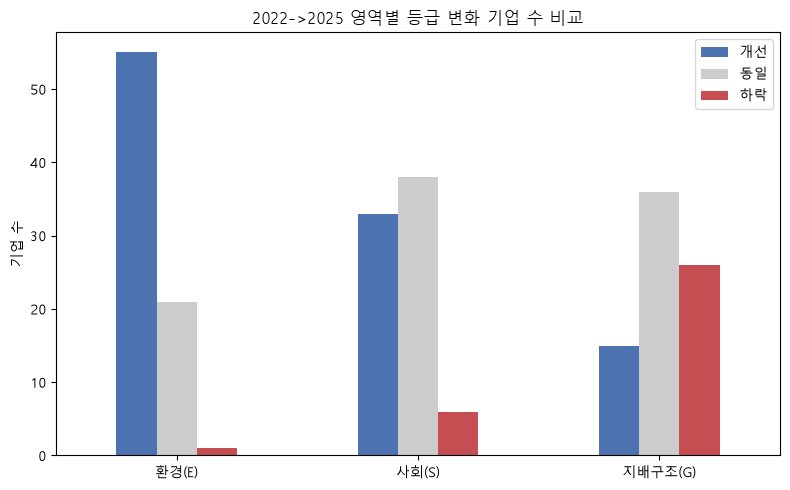

In [100]:
domains = [('환경_점수', '환경(E)'), ('사회_점수', '사회(S)'), ('지배구조_점수', '지배구조(G)')]

domain_change = {}
for col, label in domains:
    pivot = df_scored.pivot_table(index='기업명', columns='평가년도', values=col)
    cdf = pivot.dropna(subset=[first_year, last_year]).copy()
    cdf['변화량'] = cdf[last_year] - cdf[first_year]
    domain_change[label] = cdf

change_stats = pd.DataFrame({
    label: {
        '개선': (cdf['변화량'] > 0).sum(),
        '동일': (cdf['변화량'] == 0).sum(),
        '하락': (cdf['변화량'] < 0).sum(),
        '평균 변화량': cdf['변화량'].mean(),
    }
    for label, cdf in domain_change.items()
}).T
display(change_stats)

fig, ax = plt.subplots(figsize=(8, 5))
change_stats[['개선', '동일', '하락']].plot(kind='bar', ax=ax, color=['#4C72B0', '#CCCCCC', '#C44E52'])
ax.set_title(f'{first_year}->{last_year} 영역별 등급 변화 기업 수 비교')
ax.set_ylabel('기업 수')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 14. E·S·G 영역별 시가총액 상관관계 & 변동성 비교

각 영역 점수가 기업 규모(시가총액)와 얼마나 관련되는지, 그리고 기업 간 편차(변동성)가 어느 영역에서 가장 큰지 비교합니다.

,시가총액(로그)과의 스피어만 상관계수
ESG종합,0.707401
사회(S),0.688872
환경(E),0.621924
지배구조(G),0.577042


,평균 점수,표준편차(변동성)
환경(E),2.684350,1.470849
사회(S),3.042440,1.938771
지배구조(G),2.331565,1.364008


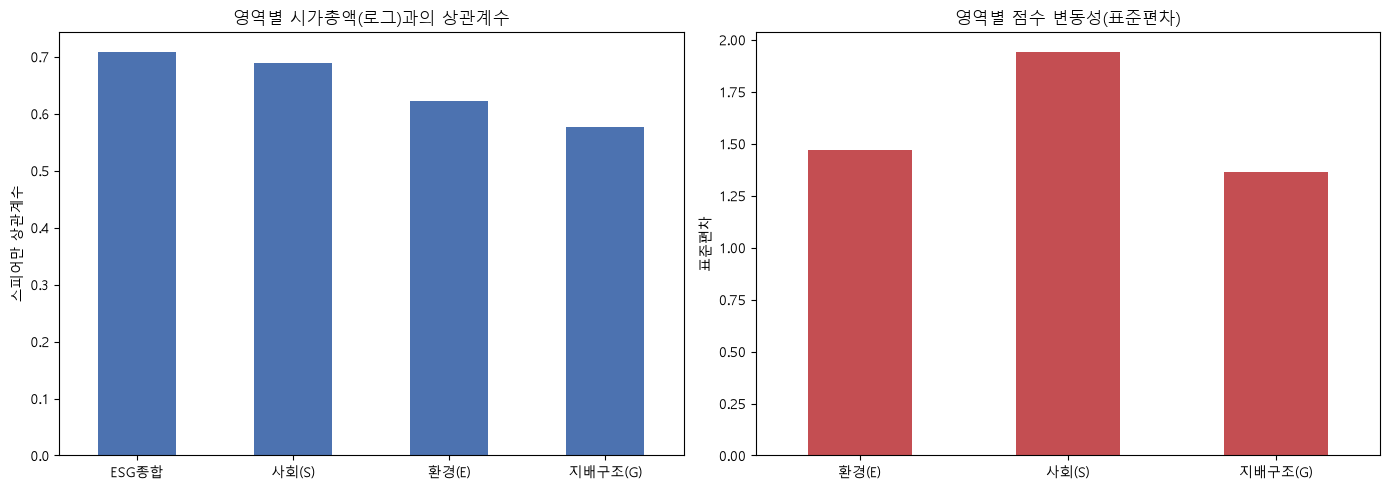

In [101]:
corr_by_domain = {}
for col, label in domains + [('ESG_점수', 'ESG종합')]:
    corr_by_domain[label] = df_latest[col].corr(log_cap, method='spearman')
corr_series = pd.Series(corr_by_domain).sort_values(ascending=False)
display(corr_series.rename('시가총액(로그)과의 스피어만 상관계수').to_frame())

volatility = df_scored[[c for c, _ in domains]].std().rename(index=dict(domains))
mean_score = df_scored[[c for c, _ in domains]].mean().rename(index=dict(domains))
domain_summary = pd.DataFrame({'평균 점수': mean_score, '표준편차(변동성)': volatility})
display(domain_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
corr_series.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('영역별 시가총액(로그)과의 상관계수')
axes[0].set_ylabel('스피어만 상관계수')
axes[0].tick_params(axis='x', rotation=0)

domain_summary['표준편차(변동성)'].plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('영역별 점수 변동성(표준편차)')
axes[1].set_ylabel('표준편차')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 15. E·S·G 영역별 시장구분(KOSPI/KOSDAQ) 격차 비교

KOSPI와 KOSDAQ 기업 간 점수 격차가 어느 영역에서 가장 크게 벌어지는지 확인합니다.

,환경(E),사회(S),지배구조(G)
시장구분,,,
KOSDAQ,2.172131,2.573770,2.024590
KOSPI,2.929412,3.266667,2.478431
격차(KOSPI-KOSDAQ),0.757281,0.692896,0.453841


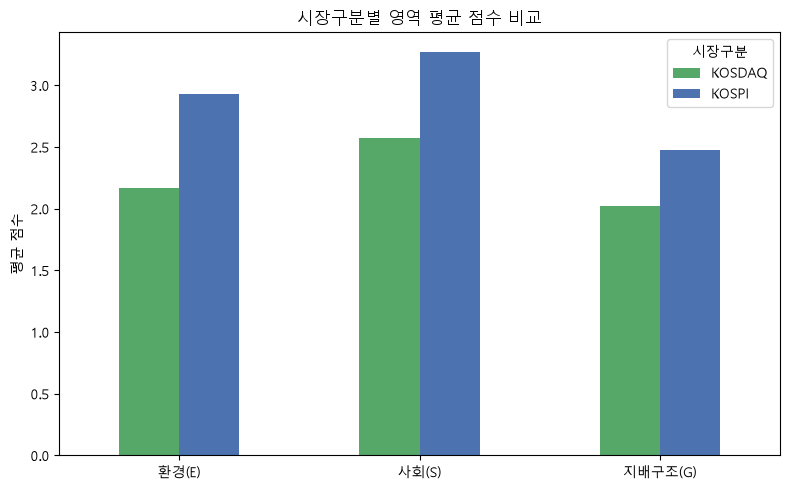

In [102]:
market_gap = df_scored.groupby('시장구분')[[c for c, _ in domains]].mean().rename(columns=dict(domains))
market_gap.loc['격차(KOSPI-KOSDAQ)'] = market_gap.loc['KOSPI'] - market_gap.loc['KOSDAQ']
display(market_gap)

fig, ax = plt.subplots(figsize=(8, 5))
market_gap.loc[['KOSDAQ', 'KOSPI']].T.plot(kind='bar', ax=ax, color=['#55A868', '#4C72B0'])
ax.set_title('시장구분별 영역 평균 점수 비교')
ax.set_ylabel('평균 점수')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 16. E·S·G 영역별 보고서 발행 효과 비교

보고서 발행 여부(8번)에 따른 점수 차이가 어느 영역에서 가장 뚜렷한지 비교합니다.

,환경(E),사회(S),지배구조(G)
보고서_발행_유형,,,
둘 다 발행,4.681818,5.363636,3.772727
지속가능경영만,3.500000,5.000000,3.000000
지배구조만,3.333333,4.166667,2.222222
미발행,2.513433,2.817910,2.238806


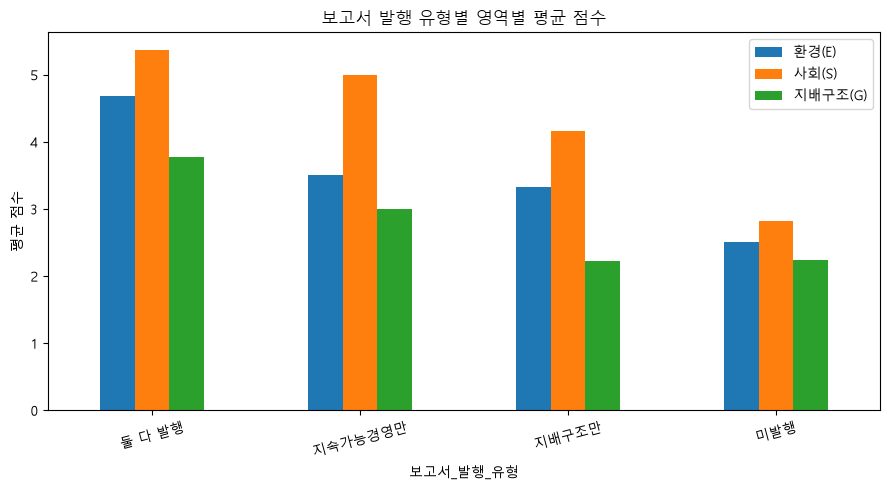

In [103]:
report_by_domain = df_scored.groupby('보고서_발행_유형')[[c for c, _ in domains]].mean().rename(columns=dict(domains))
report_by_domain = report_by_domain.loc[report_by_domain.mean(axis=1).sort_values(ascending=False).index]
display(report_by_domain)

fig, ax = plt.subplots(figsize=(9, 5))
report_by_domain.plot(kind='bar', ax=ax)
ax.set_title('보고서 발행 유형별 영역별 평균 점수')
ax.set_ylabel('평균 점수')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## 17. E·S·G 영역별 종합 인사이트

- **[연도별 변화]** 2022→2025년 사이 환경(E)은 평균 +1.03점으로 가장 크게 개선된 반면, 지배구조(G)는 평균 -0.21점으로 유일하게 하락한 영역입니다.
- **[시가총액 연관성]** 사회(S)가 시가총액(로그)과 가장 높은 상관관계(ρ=0.689)를 보이고, 지배구조(G)가 가장 약합니다(ρ=0.577). 기업 규모가 클수록 사회 점수가 좋을 가능성이 가장 큽니다.
- **[변동성]** 사회(S)는 기업 간 점수 편차(표준편차 1.94)가 가장 커 기업별 격차가 뚜렷하고, 지배구조(G)는 편차(1.36)가 가장 작아 대부분 기업이 비슷한 수준입니다.
- **[평균 수준]** 세 영역 중 지배구조(G)의 평균 점수(2.33점)가 가장 낮아, 전반적으로 기업들의 취약 영역으로 나타납니다.
- **[보고서 발행 효과]** 두 보고서를 모두 발행한 기업군이 세 영역 모두에서 평균 점수가 가장 높으며, 그 격차는 사회(S) 영역에서 가장 크게 벌어집니다(2.55점 차이).
- **[데이터 유의사항]** 전체 377행, 118개 기업이 전부 '전기·전자' 단일 업종에 속해 있어 업종 간 비교는 성립하지 않아 노트북에서 제외했습니다 (12번 섹션 참고).

## 부록. WICS 업종 세분류 매핑 시도

전체 데이터가 KRX '전기·전자' 단일 대분류에 속해 있어(12번 참고), WiseIndex의 WICS 중분류를 기업코드로 조인해 더 세분화된 업종 구분을 시도합니다.

> 참고: WiseIndex `GetIndexComponets` API는 4자리 중분류 코드까지만 지원하며(6자리 소분류 코드는 항상 빈 결과 반환), 요청 시점 기준 최근 유효 영업일 데이터를 자동으로 찾아 사용합니다.

In [ ]:
import requests
import pandas as pd
import time

# WiseIndex API는 4자리 중분류까지만 지원 (6자리 소분류 코드는 항상 빈 리스트 반환)
WICS_CODES = {
    'G4520': '기술하드웨어와장비',
    'G4530': '반도체와반도체장비',
    'G4535': '전자와전기제품',
    'G4540': '디스플레이',
}

def find_valid_wics_date(sec_cd='G4530', start=None, max_back=30):
    """미래/데이터 없는 날짜는 빈 리스트를 반환하므로, 데이터가 있는 가장 최근 영업일을 뒤로 탐색"""
    dt = start or pd.Timestamp.today()
    for _ in range(max_back):
        if dt.weekday() < 5:
            ds = dt.strftime('%Y%m%d')
            url = f"http://www.wiseindex.com/Index/GetIndexComponets?ceil_yn=0&dt={ds}&sec_cd={sec_cd}"
            r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=10)
            if r.json().get('list'):
                return ds
        dt -= pd.Timedelta(days=1)
    raise RuntimeError("유효한 WICS 데이터 날짜를 찾지 못했습니다.")

def fetch_wics_mapping(dt=None):
    dt = dt or find_valid_wics_date()
    rows = []
    for code, name in WICS_CODES.items():
        url = f"http://www.wiseindex.com/Index/GetIndexComponets?ceil_yn=0&dt={dt}&sec_cd={code}"
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
        data = r.json()
        for item in data.get('list', []):
            rows.append({
                '기업코드': item['CMP_CD'],
                'WICS_중분류': name,
                'WICS_코드': code,
            })
        time.sleep(1)  # 서버 부하 방지
    return pd.DataFrame(rows).drop_duplicates(subset='기업코드')

wics_df = fetch_wics_mapping()
print(f"WICS 매핑 확보: {len(wics_df)}개 종목")

# --- 우리 데이터와 조인 ---
df['기업코드'] = df['기업코드'].astype(str).str.zfill(6)
wics_df['기업코드'] = wics_df['기업코드'].astype(str).str.zfill(6)

df_merged = df.merge(wics_df[['기업코드', 'WICS_중분류']], on='기업코드', how='left')

matched = df_merged['WICS_중분류'].notna().sum()
unmatched = df_merged[df_merged['WICS_중분류'].isna()]['기업명'].unique()
print(f"매칭: {matched}/{len(df_merged)}건")
print(f"미매칭 기업 ({len(unmatched)}개) — 다른 WICS 대분류(소재/산업재 등)에 속할 가능성:")
print(list(unmatched))

# --- 매칭 결과 샘플 확인 ---
print("\n--- 매칭 결과 샘플 (업종명 vs WICS_중분류) ---")
display(df_merged[['기업명', '기업코드', '평가년도', 'ESG등급', '업종명', 'WICS_중분류']].head(15))

print("\n--- WICS_중분류 분포 (전체 기준, NaN=미매칭) ---")
display(df_merged['WICS_중분류'].value_counts(dropna=False).rename('건수').to_frame())
